In [43]:
from Autograd import Tensor
from Activation import ReLU
from Loss import cross_entropy_loss
from Model import Linear,Sequential,Layernorm,Embedding,Flatten,Module
from Optimiser import SGD,Momentum,Adagrad,RMSProp,Adadelta,Adam
from Training import training
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [53]:
class Attention(Module):
    def __init__(self,value_dim,query_dim,embedding_dim,block_size):
        self.value_dim=value_dim
        self.query_dim=query_dim
        self.embedding_dim=embedding_dim
        self.mask=np.triu(np.ones((block_size,block_size)),k=1)
        self.Wv=Tensor(np.random.rand(embedding_dim,value_dim)*np.sqrt(2/(embedding_dim+value_dim)),requires_grad=True)
        self.Wk=Tensor(np.random.rand(embedding_dim,query_dim)*np.sqrt(2/(embedding_dim+query_dim)),requires_grad=True)
        self.Wq=Tensor(np.random.rand(embedding_dim,query_dim)*np.sqrt(2/(embedding_dim+query_dim)),requires_grad=True)
    def forward(self,x):
        v=x@self.Wv
        k=x@self.Wk
        q=x@self.Wq
        presoftmax=q@k.transpose()/self.query_dim**0.5
        presoftmax=presoftmax+Tensor(np.where(self.mask,-np.inf,0))
        softmax=presoftmax.softmax()
        return softmax@v

In [ ]:
def data_read(prop):
    df=pd.read_csv("names.txt",header=None)
    data_list=df[0].tolist()
    random.shuffle(data_list)
    chars=sorted(set("".join(data_list)))
    chars.append(".")
    encodedict={}
    decodedict={}
    for id,char in enumerate(chars):
        encodedict[char]=id
        decodedict[id]=char
    length=len(data_list)
    n=int(length*prop)
    train_set=data_list[:n]
    test_set=data_list[n:]
    return train_set,test_set,encodedict,decodedict

def encode(name):
    return [encodedict["."]]+[encodedict[ch] for ch in name]+[encodedict["."]]

def decode(sequence):
    return "".join([decodedict[id] for id in sequence])

def tokeniser(data,block_size):
    tokens=encode(".".join(data))
    X=[]
    Y=[]
    for i in range(len(tokens)-block_size):
        X.append(tokens[i:i+block_size])
        Y.append(tokens[i+block_size])
    return X,Y

In [62]:
block_size=3

train_set,test_set,encodedict,decodedict=data_read(0.5)
X,Y=tokeniser(train_set,block_size)
X,Y=Tensor(X),Tensor(Y)
no_characters=len(encodedict)

In [63]:
embedding_dim=15

value_dim=10
query_dim=10

In [64]:
class FFN(Module):
    def __init__(self,input_dim,output_dim,hidden_dim=128):
        self.ffn=Sequential([Linear(input_dim,hidden_dim),ReLU(),Linear(hidden_dim,output_dim)])
    def forward(self,x):
        return self.ffn.forward_prop(x)

In [66]:
class Transformer(Module):
    def __init__(self,embedding_dim,query_dim,vocab_size,block_size,hidden_dim):
        self.block_size=block_size
        self.token_embedding=Embedding(vocab_size,embedding_dim)
        self.position_embedding=Embedding(block_size,embedding_dim)
        self.attention=Attention(embedding_dim,query_dim,embedding_dim,block_size)
        self.layernorm1=Layernorm(embedding_dim)
        self.ff=FFN(embedding_dim,embedding_dim,hidden_dim)
        self.layernorm2=Layernorm(embedding_dim)
        self.linear=Linear(embedding_dim,vocab_size)
    def forward_prop(self,x):
        embedding_out=self.token_embedding.forward(x)+self.position_embedding.forward(Tensor(np.arange(self.block_size),requires_grad=False))
        attention_scores=self.attention.forward(embedding_out)
        layernormed=self.layernorm1.forward(embedding_out+attention_scores)
        ffn=self.ff.forward(layernormed)
        layernormed2=self.layernorm2.forward(layernormed+ffn)
        linear_classification=self.linear.forward(layernormed2[:,-1,:])
        return linear_classification

In [67]:
model=Transformer(embedding_dim,query_dim,no_characters,block_size,128)
loss_fn=cross_entropy_loss
optimiser=Adam(model.parameters())
loss=training(X,model,Y,loss_fn,250,optimiser,64)

np.float64(2.1229462390361955)

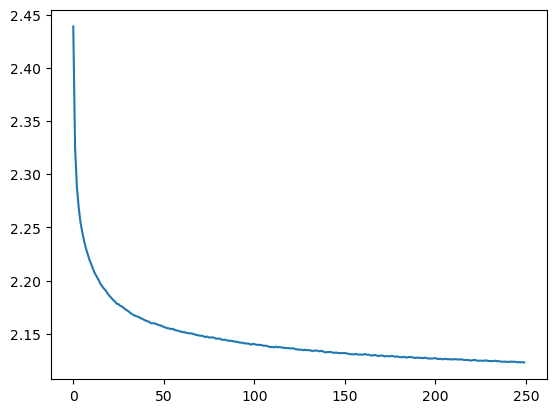

In [68]:
plt.plot(loss)
loss[-1]

In [211]:
start_name="rik"
iterations=1000
trials=[]
for i in range(iterations):
    name=start_name
    final=[ch for ch in name]
    letter=name[-1]
    while letter!=".":
        tokenised=encode(name)
        tokenised.pop(0)
        tokenised.pop(-1)
        dist=model.forward_prop(Tensor([tokenised])).softmax().data
        probs=dist[0]
        next_id=np.random.choice(len(probs),p=probs)
        letter=decodedict[next_id]
        final.append(letter)
        name=name[1:]+letter
    final_name="".join(final)
    trials.append(final_name[:-1])

name=start_name
final=[ch for ch in name]
letter=name[-1]
while letter!=".":
    tokenised=encode(name)
    tokenised.pop(0)
    tokenised.pop(-1)
    dist=model.forward_prop(Tensor([tokenised])).softmax().data
    probs=dist[0]
    next_id=np.argmax(probs)
    letter=decodedict[next_id]
    final.append(letter)
    name=name[1:]+letter
greedy_name="".join(final[:-1])

from collections import Counter

counts=Counter(trials)
df=pd.DataFrame(counts.items(),columns=["Names","Counter"]).sort_values(by="Counter",ascending=False)
df.head(10)

,Names,Counter
3,rik,549
1,rika,121
8,riko,25
19,rike,17
30,riks,12
58,rikah,5
96,riki,5
112,riky,5
34,rikt,4
68,rikon,4
